<a href="https://colab.research.google.com/github/sabithakrishnan/timeseries-analysis/blob/main/timeseries_analysis_random_forest.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

/tmp/ipykernel_805/296505200.py:7: FutureWarning: Support for nested sequences for 'parse_dates' in pd.read_csv is deprecated. Combine the desired columns with pd.to_datetime after parsing instead.
  df = pd.read_csv(url, sep=';', decimal=',', parse_dates=[['Date', 'Time']], dayfirst=True)
/tmp/ipykernel_805/296505200.py:7: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df = pd.read_csv(url, sep=';', decimal=',', parse_dates=[['Date', 'Time']], dayfirst=True)
/tmp/ipykernel_805/296505200.py:20: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  ts_data = df['CO(GT)'].ffill().astype(float)


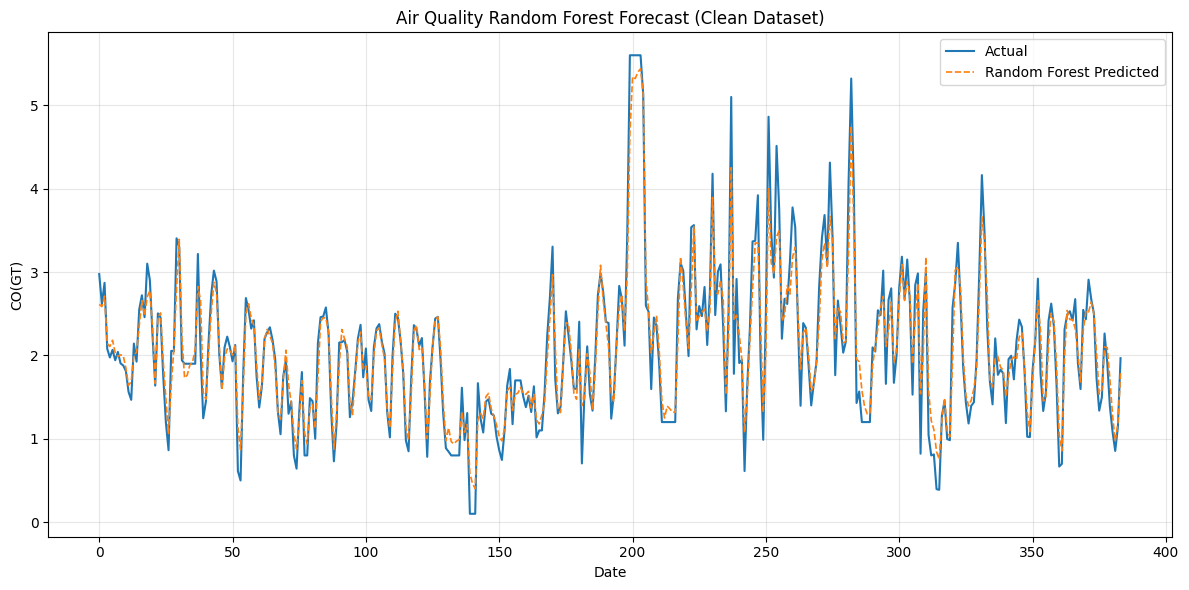

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor

# 1. Load and Preprocess the UCI Air Quality Dataset
url = "/content/AirQualityUCI.csv"
df = pd.read_csv(url, sep=';', decimal=',', parse_dates=[['Date', 'Time']], dayfirst=True)

# Clean dataset structure
df.dropna(how='all', inplace=True)
df = df.iloc[:, :15]

# Convert and index datetime
df['Date_Time'] = pd.to_datetime(df['Date_Time'], format='%d/%m/%Y %H.%M.%S', errors='coerce')
df.dropna(subset=['Date_Time'], inplace=True)
df.set_index('Date_Time', inplace=True)

# Replace missing values (-200) and forward fill
df.replace(-200, pd.NA, inplace=True)
ts_data = df['CO(GT)'].ffill().astype(float)

# Resample to daily frequency to match the target data density
ts_data = ts_data.resample('D').mean().ffill()

# 2. Convert Time Series to Supervised Learning (Lag Features)
# We will use the past 7 days of CO levels to predict today's level
look_back = 7
data_dict = {'Target': ts_data}

for i in range(1, look_back + 1):
    data_dict[f'Lag_{i}'] = ts_data.shift(i)

features_df = pd.DataFrame(data_dict).dropna()

# Split into inputs (X) and target outputs (y)
X = features_df.drop(columns=['Target'])
y = features_df['Target']

# 3. Train Random Forest Model & Predict
# n_estimators controls the number of trees; random_state ensures reproducible plots
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X, y)

# Generate in-sample historical predictions
predictions = rf_model.predict(X)

# 4. Generate the Chart to Match Your Image Style
plt.figure(figsize=(12, 6), dpi=100)

# Reset index to match the integer timeline (0 to 1750+) from your reference graph
actual_values = y.reset_index(drop=True)

# Plot actual historical data
plt.plot(actual_values, label='Actual', color='#1f77b4', linestyle='-', linewidth=1.5)

# Plot Random Forest predictions as a dashed overlay
plt.plot(predictions, label='Random Forest Predicted', color='#ff7f0e', linestyle='--', linewidth=1.2)

# Customizing layout to match chart aesthetics
plt.title('Air Quality Random Forest Forecast (Clean Dataset)', fontsize=12)
plt.xlabel('Date', fontsize=10)
plt.ylabel('CO(GT)', fontsize=10)
plt.legend(loc='upper right')

# Subtle grid styling matching the reference image
plt.grid(True, linestyle='-', alpha=0.3)

# Display final graph
plt.tight_layout()
plt.show()
